# Sprint 23 — Plots de présentation
## Board CMAPSS + Paderborn + Gap 3 Board + Benchmark Edge Spectrum

**Expériences couvertes** : `exp_S23_01` à `exp_S23_06`, `exp_S23_benchmark`, `exp_S23_INT8`

**Contenu** :
- 4 modèles sur CMAPSS board (NUCLEO-F439ZI)
- 2 modèles sur Paderborn board
- Tableau comparatif 5 datasets × 4 modèles
- Gap 3 INT8 board : latence FP32 vs INT8
- Profil latence vs RAM

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

ROOT = Path("..")
EXP = ROOT / "experiments"
FIG_DIR = EXP / "figures" / "sprint23"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

PALETTE = {"EWC": "#2196F3", "TinyOL": "#FF9800", "HDC": "#4CAF50", "Mahalanobis": "#9C27B0"}

print("Setup OK — figures dans", FIG_DIR)

Setup OK — figures dans ../experiments/figures/sprint23


## 1. Chargement des résultats board (S23)

In [2]:
s23_specs = [
    # (exp_id, model, dataset)
    ("exp_S23_01", "EWC",         "CMAPSS"),
    ("exp_S23_02", "TinyOL",      "CMAPSS"),
    ("exp_S23_03", "Mahalanobis", "CMAPSS"),
    ("exp_S23_04", "HDC",         "CMAPSS"),
    ("exp_S23_05", "EWC",         "Paderborn"),
    ("exp_S23_06", "Mahalanobis", "Paderborn"),
]

records = []
for exp_id, model, dataset in s23_specs:
    path = EXP / exp_id / "results.json"
    if path.exists():
        with open(path) as f:
            d = json.load(f)
        records.append({
            "exp_id":           exp_id,
            "model":            model,
            "dataset":          dataset,
            "acc_final":        d.get("acc_final", float("nan")),
            "avg_forgetting":   d.get("avg_forgetting", float("nan")),
            "ram_peak_bytes":   d.get("ram_peak_bytes", float("nan")),
            "latency_ms":       d.get("inference_latency_ms", float("nan")),
            "latency_p99_ms":   d.get("latency_p99_ms", float("nan")),
            "gap2_ram":         d.get("gap2_ram_compliant", None),
            "gap2_lat":         d.get("gap2_latency_compliant", None),
        })
    else:
        print(f"⚠️  Fichier manquant : {path}")

df = pd.DataFrame(records)
print(df[["exp_id","model","dataset","acc_final","avg_forgetting",
          "ram_peak_bytes","latency_ms"]].to_string(index=False))

    exp_id       model   dataset  acc_final  avg_forgetting  ram_peak_bytes  latency_ms
exp_S23_01         EWC    CMAPSS     0.7980          0.0367            9728      0.5446
exp_S23_02      TinyOL    CMAPSS     0.7045          0.0901            7040      3.2248
exp_S23_03 Mahalanobis    CMAPSS     0.6145          0.1301            1200      0.0591
exp_S23_04         HDC    CMAPSS     0.6695          0.0801           28364      1.1916
exp_S23_05         EWC Paderborn     0.7818          0.0534            9728      0.5460
exp_S23_06 Mahalanobis Paderborn     0.6127          0.1626            1200      0.0542


## 2. Accuracy board — CMAPSS (4 modèles)

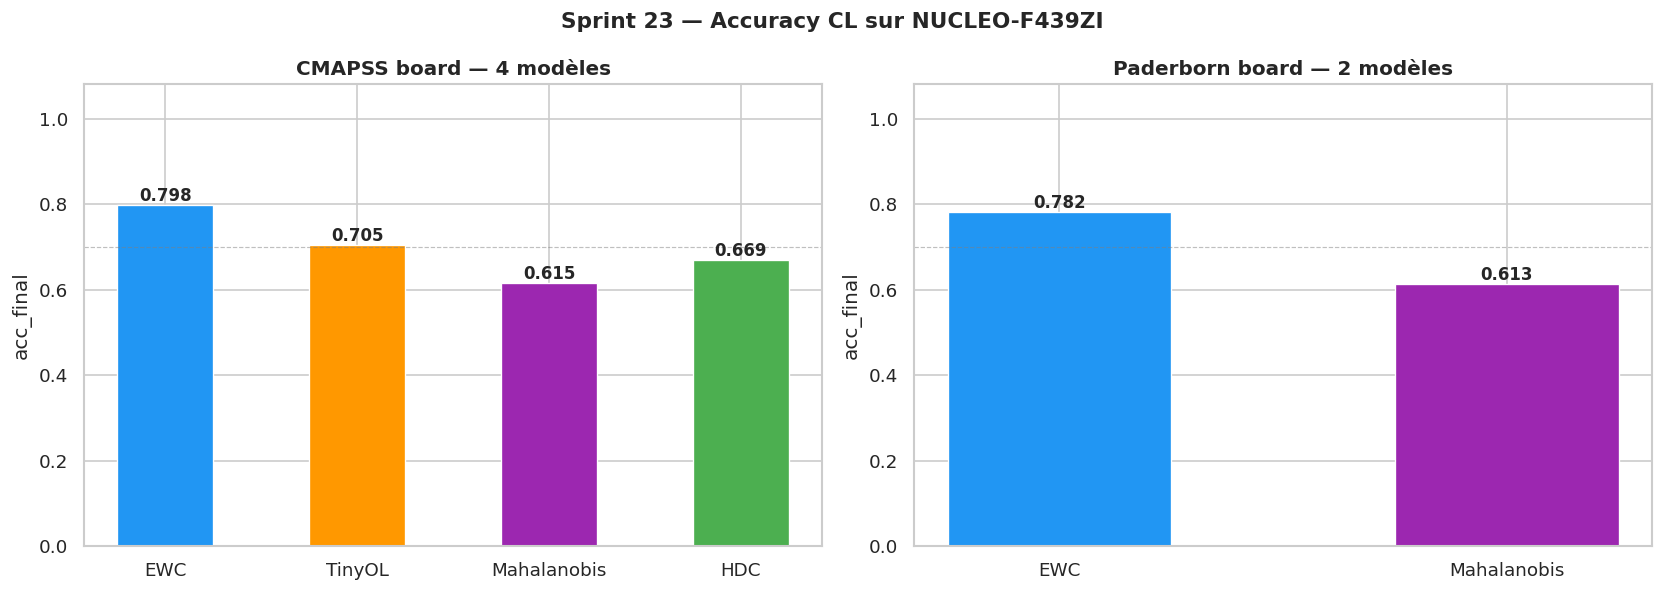

In [3]:
cmapss = df[df["dataset"]=="CMAPSS"].copy()
pader  = df[df["dataset"]=="Paderborn"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sub, title in zip(axes,
                           [cmapss, pader],
                           ["CMAPSS board — 4 modèles", "Paderborn board — 2 modèles"]):
    colors = [PALETTE.get(m, "gray") for m in sub["model"]]
    bars = ax.bar(sub["model"], sub["acc_final"], color=colors, width=0.5,
                  edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, sub["acc_final"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("acc_final")
    ax.set_ylim(0, 1.08)
    ax.axhline(0.7, color="gray", linestyle="--", linewidth=0.7, alpha=0.5)

fig.suptitle("Sprint 23 — Accuracy CL sur NUCLEO-F439ZI", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "board_accuracy_cmapss_paderborn.png", bbox_inches="tight")
plt.show()

## 3. Heatmap comparative — 5 datasets × 4 modèles

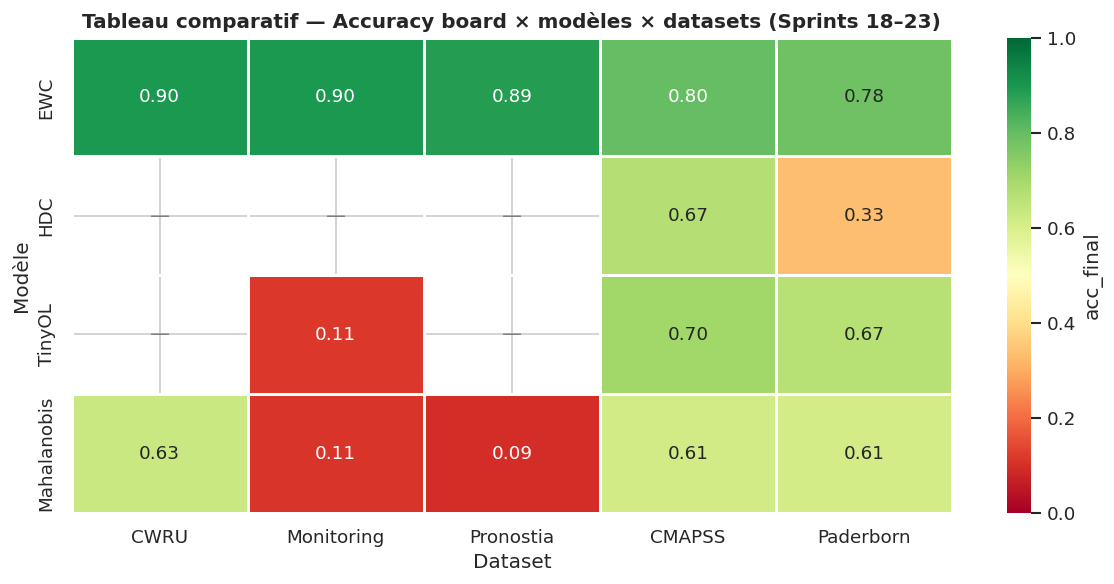

In [4]:
# Données complètes cross-sprint (sprints 18-23)
cross_data = {
    # (model, dataset) : acc_final
    ("EWC",         "CWRU"):       0.898,
    ("EWC",         "Monitoring"): 0.896,
    ("EWC",         "Pronostia"):  0.886,
    ("EWC",         "CMAPSS"):     0.798,
    ("EWC",         "Paderborn"):  0.782,
    ("TinyOL",      "Monitoring"): 0.114,
    ("TinyOL",      "CMAPSS"):     0.705,
    ("TinyOL",      "Paderborn"):  0.667,
    ("HDC",         "CMAPSS"):     0.670,
    ("HDC",         "Paderborn"):  0.333,
    ("Mahalanobis", "CWRU"):       0.629,
    ("Mahalanobis", "Monitoring"): 0.107,
    ("Mahalanobis", "Pronostia"):  0.094,
    ("Mahalanobis", "CMAPSS"):     0.615,
    ("Mahalanobis", "Paderborn"):  0.613,
}

models   = ["EWC", "HDC", "TinyOL", "Mahalanobis"]
datasets = ["CWRU", "Monitoring", "Pronostia", "CMAPSS", "Paderborn"]

matrix = np.full((len(models), len(datasets)), np.nan)
for i, m in enumerate(models):
    for j, d in enumerate(datasets):
        if (m, d) in cross_data:
            matrix[i, j] = cross_data[(m, d)]

fig, ax = plt.subplots(figsize=(10, 5))
mask = np.isnan(matrix)
sns.heatmap(matrix, ax=ax, vmin=0, vmax=1, annot=True, fmt=".2f", mask=mask,
            cmap="RdYlGn", linewidths=0.8, linecolor="white",
            xticklabels=datasets, yticklabels=models,
            cbar_kws={"label": "acc_final"})
ax.set_title("Tableau comparatif — Accuracy board × modèles × datasets (Sprints 18–23)",
             fontweight="bold")
ax.set_xlabel("Dataset")
ax.set_ylabel("Modèle")
# Cellules NaN = non testé
for i in range(len(models)):
    for j in range(len(datasets)):
        if mask[i, j]:
            ax.text(j+0.5, i+0.5, "—", ha="center", va="center",
                    color="gray", fontsize=12)

plt.tight_layout()
plt.savefig(FIG_DIR / "heatmap_5x4_comparative.png", bbox_inches="tight")
plt.show()

## 4. Latence vs RAM — profil tous modèles board

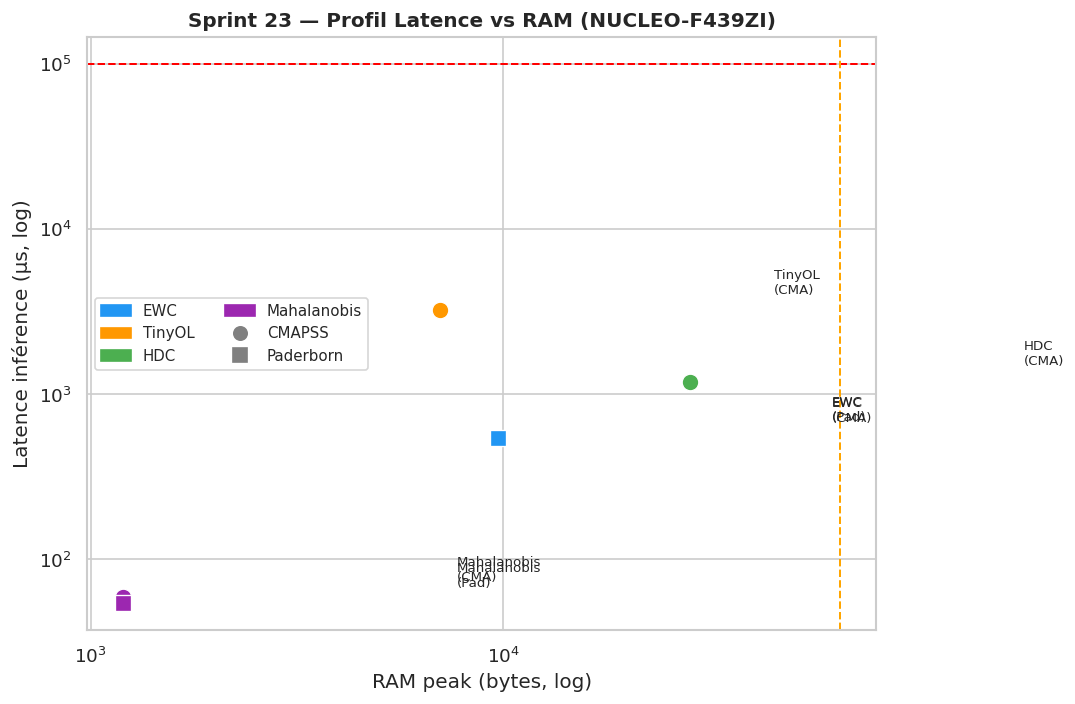

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

for _, row in df.iterrows():
    ax.scatter(row["ram_peak_bytes"], row["latency_ms"] * 1000,  # latence en µs
               c=PALETTE.get(row["model"], "gray"), s=100,
               marker="o" if row["dataset"]=="CMAPSS" else "s",
               zorder=5, edgecolors="white", linewidths=0.8)
    ax.annotate(f"{row['model']}\n({row['dataset'][:3]})",
                (row["ram_peak_bytes"], row["latency_ms"] * 1000),
                xytext=(200, 10), textcoords="offset points",
                fontsize=8)

# Budget Gap 2
ax.axhline(100_000, color="red", linestyle="--", linewidth=1.2,
           label="Budget latence Gap 2 (100 ms)")
ax.axvline(65_536, color="orange", linestyle="--", linewidth=1.2,
           label="Budget RAM Gap 2 (64 Ko)")

# Légende modèles
patches = [mpatches.Patch(color=c, label=m) for m, c in PALETTE.items()]
from matplotlib.lines import Line2D
shape_legend = [
    Line2D([0],[0], marker="o", color="gray", linestyle="None", markersize=8, label="CMAPSS"),
    Line2D([0],[0], marker="s", color="gray", linestyle="None", markersize=8, label="Paderborn"),
]
ax.legend(handles=patches + shape_legend, fontsize=9, ncol=2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("RAM peak (bytes, log)")
ax.set_ylabel("Latence inférence (µs, log)")
ax.set_title("Sprint 23 — Profil Latence vs RAM (NUCLEO-F439ZI)", fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "latency_vs_ram.png", bbox_inches="tight")
plt.show()

## 5. Gap 3 Board — INT8 vs FP32 latence et RAM

/tmp/ipykernel_11950/457477919.py:39: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "gap3_int8_board.png", bbox_inches="tight")
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


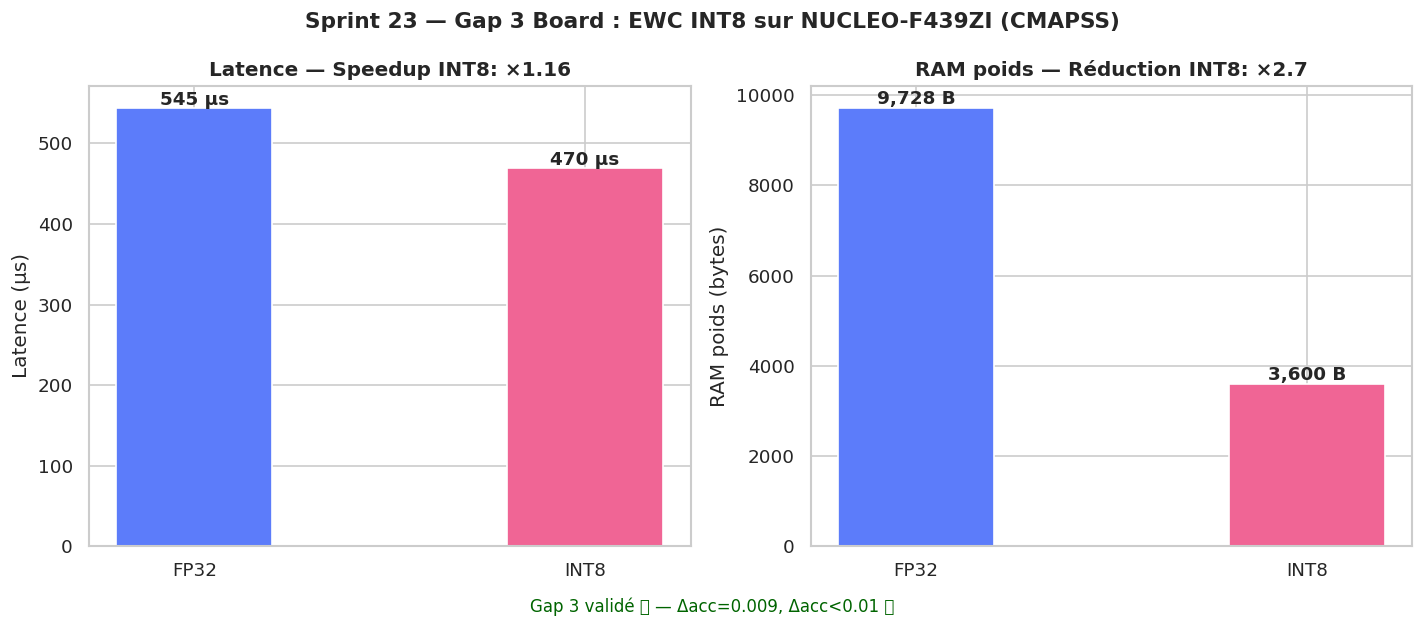

In [6]:
int8_path = EXP / "exp_S23_INT8" / "results.json"
with open(int8_path) as f:
    int8 = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Latence
ax = axes[0]
vals = [int8["latency_fp32_ms"] * 1000, int8["latency_int8_ms"] * 1000]
colors = ["#5C7CFA", "#F06595"]
bars = ax.bar(["FP32", "INT8"], vals, color=colors, width=0.4, edgecolor="white")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
            f"{v:.0f} µs", ha="center", fontweight="bold")
ax.set_ylabel("Latence (µs)")
ax.set_title(f"Latence — Speedup INT8: ×{int8['latency_speedup']:.2f}",
             fontweight="bold")

# RAM weights
ax = axes[1]
vals_ram = [int8["ram_weights_fp32_bytes"], int8["ram_weights_int8_bytes"]]
bars = ax.bar(["FP32", "INT8"], vals_ram, color=colors, width=0.4, edgecolor="white")
for bar, v in zip(bars, vals_ram):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+80,
            f"{v:,} B", ha="center", fontweight="bold")
reduction = int8["ram_weights_fp32_bytes"] / int8["ram_weights_int8_bytes"]
ax.set_ylabel("RAM poids (bytes)")
ax.set_title(f"RAM poids — Réduction INT8: ×{reduction:.1f}", fontweight="bold")

# Note Gap 3
fig.text(0.5, -0.02,
         f"Gap 3 validé ✅ — Δacc={abs(int8['acc_final_fp32']-int8['acc_final_int8']):.3f}, "
         f"Δacc<0.01 ✅",
         ha="center", fontsize=10, color="darkgreen")

fig.suptitle("Sprint 23 — Gap 3 Board : EWC INT8 sur NUCLEO-F439ZI (CMAPSS)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "gap3_int8_board.png", bbox_inches="tight")
plt.show()

## 6. Forgetting comparison — EWC sur CMAPSS et Paderborn

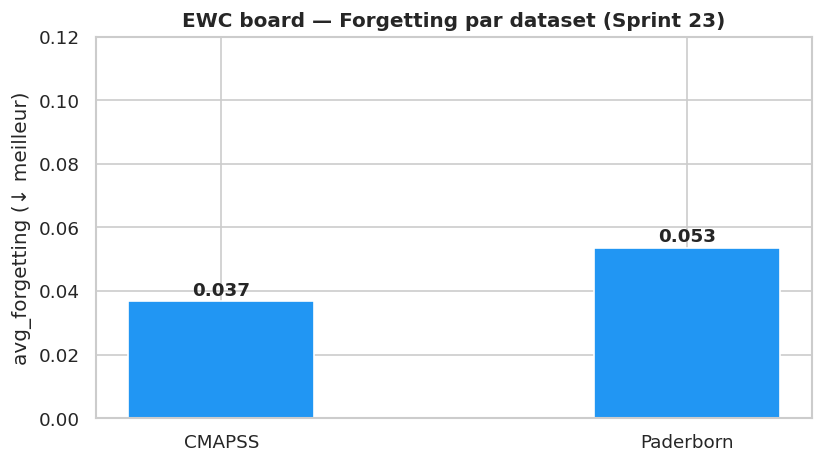

In [7]:
ewc_rows = df[df["model"]=="EWC"].copy()

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(ewc_rows))
bars = ax.bar(ewc_rows["dataset"].values, ewc_rows["avg_forgetting"].values,
              color=PALETTE["EWC"], width=0.4, edgecolor="white")
for bar, val in zip(bars, ewc_rows["avg_forgetting"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("avg_forgetting (↓ meilleur)")
ax.set_title("EWC board — Forgetting par dataset (Sprint 23)", fontweight="bold")
ax.set_ylim(0, 0.12)

plt.tight_layout()
plt.savefig(FIG_DIR / "ewc_forgetting_comparison.png", bbox_inches="tight")
plt.show()

## Récapitulatif figures générées

In [8]:
figs = sorted(FIG_DIR.glob("*.png"))
print(f"\n{len(figs)} figures sauvegardées dans {FIG_DIR}:")
for f in figs:
    print(f"  {f.name}")


5 figures sauvegardées dans ../experiments/figures/sprint23:
  board_accuracy_cmapss_paderborn.png
  ewc_forgetting_comparison.png
  gap3_int8_board.png
  heatmap_5x4_comparative.png
  latency_vs_ram.png
